# Stock Trend Prediction using Candlestick Images

This notebook keeps the full assignment in one place. The current implementation covers **Task 1: Dataset Collection & Preprocessing**, **Task 2: Labeling Strategy**, and **Task 3: Dataset Preparation**.

Pipeline implemented here:
- Download 2 years of 1-hour intraday NSE stock data with `yfinance`.
- Convert timestamps to **IST / Asia-Kolkata** and keep regular NSE session candles.
- Build each image from the previous 3 trading days, using exactly **18 candles** per image.
- Label each image by the next trading day's close-to-close movement using a stock-specific volatility threshold.
- Keep all three labels: **down**, **neutral**, and **up**.
- Save uniform candlestick PNG images.
- Split images chronologically into Train / Validation / Test folders using 70% / 20% / 10%, with a purge gap at split boundaries to avoid overlapping-window leakage.
- Create class mappings and split manifest CSV files so each image path has a verified label.

## 0. Install Dependencies

Run this cell once if the required packages are not already installed.

In [1]:
%pip install -q yfinance mplfinance pandas numpy matplotlib pillow tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and Configuration

In [2]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw_hourly"
IMAGE_DIR = DATA_DIR / "candlestick_images_multiclass"
METADATA_PATH = DATA_DIR / "metadata_multiclass.csv"
SUMMARY_PATH = DATA_DIR / "dataset_summary_multiclass.json"
MANIFEST_DIR = DATA_DIR / "manifests_multiclass"
CLASS_MAPPING_PATH = DATA_DIR / "class_to_idx_multiclass.json"

IST_TIMEZONE = "Asia/Kolkata"
YFINANCE_PERIOD = "2y"
YFINANCE_INTERVAL = "1h"

# NSE regular session is 09:15-15:30 IST. Yahoo may include a final shorter candle.
# Each image uses exactly 6 candles per day x 3 days = 18 candles.
MARKET_OPEN = "09:15"
MARKET_CLOSE = "15:30"
CANDLES_PER_DAY = 6
LOOKBACK_DAYS = 3
WINDOW_CANDLES = CANDLES_PER_DAY * LOOKBACK_DAYS

RESAMPLE_FILTER = getattr(getattr(Image, "Resampling", Image), "LANCZOS")

IMAGE_SIZE = (224, 224)
IMAGE_DPI = 100

# Task 2 labeling strategy: stock-specific volatility threshold.
# threshold_t = max(0.5 * rolling_20_day_volatility_t, 0.3%)
# Samples inside [-threshold_t, +threshold_t] are labeled neutral,
# giving a three-class down/neutral/up classification dataset.
VOLATILITY_LOOKBACK_DAYS = 20
VOLATILITY_MULTIPLIER = 0.5
MIN_MOVEMENT_THRESHOLD = 0.003
LABELS = ["down", "neutral", "up"]

SPLIT_RATIOS = {"train": 0.70, "validation": 0.20, "test": 0.10}
PURGE_SAMPLES_BETWEEN_SPLITS = LOOKBACK_DAYS - 1
RANDOM_SEED = 42

for directory in [DATA_DIR, RAW_DIR, IMAGE_DIR, MANIFEST_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Multiclass candlestick images will be saved under: {IMAGE_DIR}")

Project root: /kaggle/working
Multiclass candlestick images will be saved under: /kaggle/working/data/candlestick_images_multiclass


## 2. Stock Universe

`yfinance` uses the `.NS` suffix for NSE-listed stocks.

In [3]:
STOCKS = {
    "Private Banks": {
        "HDFC Bank Ltd": "HDFCBANK.NS",
        "ICICI Bank Ltd": "ICICIBANK.NS",
        "Axis Bank Ltd": "AXISBANK.NS",
        "Kotak Mahindra Bank Ltd": "KOTAKBANK.NS",
        "IndusInd Bank Ltd": "INDUSINDBK.NS",
    },
    "PSU Banks": {
        "State Bank of India": "SBIN.NS",
        "Bank of Baroda": "BANKBARODA.NS",
        "Punjab National Bank": "PNB.NS",
        "Canara Bank": "CANBK.NS",
        "Union Bank of India": "UNIONBANK.NS",
    },
    "Others": {
        "Federal Bank Ltd": "FEDERALBNK.NS",
        "IDFC First Bank Ltd": "IDFCFIRSTB.NS",
        "Bandhan Bank Ltd": "BANDHANBNK.NS",
        "RBL Bank Ltd": "RBLBANK.NS",
        "AU Small Finance Bank Ltd": "AUBANK.NS",
    },
}

stock_table = pd.DataFrame(
    [
        {"category": category, "stock_name": name, "ticker": ticker}
        for category, members in STOCKS.items()
        for name, ticker in members.items()
    ]
)

stock_table

,category,stock_name,ticker
0,Private Banks,HDFC Bank Ltd,HDFCBANK.NS
1,Private Banks,ICICI Bank Ltd,ICICIBANK.NS
2,Private Banks,Axis Bank Ltd,AXISBANK.NS
3,Private Banks,Kotak Mahindra Bank Ltd,KOTAKBANK.NS
4,Private Banks,IndusInd Bank Ltd,INDUSINDBK.NS
5,PSU Banks,State Bank of India,SBIN.NS
6,PSU Banks,Bank of Baroda,BANKBARODA.NS
7,PSU Banks,Punjab National Bank,PNB.NS
8,PSU Banks,Canara Bank,CANBK.NS
9,PSU Banks,Union Bank of India,UNIONBANK.NS


## 3. Download 1-Hour Intraday Data

Yahoo Finance usually limits intraday history to roughly the most recent 730 calendar days, so `period="2y"` is used here. All timestamps are converted to IST before preprocessing.

In [4]:
REQUIRED_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]


def safe_ticker_name(ticker: str) -> str:
    return ticker.replace(".", "_").replace("-", "_")


def flatten_yfinance_columns(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Handle both single-index and MultiIndex column formats returned by yfinance."""
    if not isinstance(df.columns, pd.MultiIndex):
        return df

    for level in range(df.columns.nlevels):
        if ticker in df.columns.get_level_values(level):
            return df.xs(ticker, axis=1, level=level)

    flattened = df.copy()
    flattened.columns = [col[0] for col in flattened.columns]
    return flattened


def ensure_ist_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    if df.index.tz is None:
        # yfinance can occasionally return naive timestamps. Treat them as UTC first,
        # then convert to IST so the downstream grouping is always explicit.
        df.index = df.index.tz_localize("UTC").tz_convert(IST_TIMEZONE)
    else:
        df.index = df.index.tz_convert(IST_TIMEZONE)

    df.index.name = "DatetimeIST"
    return df.sort_index()


def clean_price_data(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    df = flatten_yfinance_columns(df, ticker)
    df = ensure_ist_index(df)

    missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing_columns:
        raise ValueError(f"{ticker} is missing columns: {missing_columns}")

    df = df[REQUIRED_COLUMNS].copy()
    for column in REQUIRED_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["Open", "High", "Low", "Close"])
    df = df[df.index.dayofweek < 5]
    return df


def download_stock_data(ticker: str, force_download: bool = False) -> pd.DataFrame:
    raw_path = RAW_DIR / f"{safe_ticker_name(ticker)}_{YFINANCE_INTERVAL}.csv"

    if raw_path.exists() and not force_download:
        df = pd.read_csv(raw_path, parse_dates=["DatetimeIST"], index_col="DatetimeIST")
        return ensure_ist_index(df)

    df = yf.download(
        tickers=ticker,
        period=YFINANCE_PERIOD,
        interval=YFINANCE_INTERVAL,
        auto_adjust=False,
        prepost=False,
        progress=False,
        threads=False,
    )

    if df.empty:
        raise ValueError(f"No data returned for {ticker}")

    df = clean_price_data(df, ticker)
    df.to_csv(raw_path)
    return df


def download_all_stocks(force_download: bool = False) -> dict:
    downloaded = {}

    for row in tqdm(stock_table.itertuples(index=False), total=len(stock_table), desc="Downloading"):
        try:
            downloaded[row.ticker] = download_stock_data(row.ticker, force_download=force_download)
        except Exception as exc:
            print(f"Skipping {row.ticker}: {exc}")

    return downloaded


# Set force_download=True if you want to refresh all CSV files from yfinance.
hourly_data = download_all_stocks(force_download=False)
print(f"Downloaded/loaded {len(hourly_data)} stocks")

Downloading:   0%|          | 0/15 [00:00<?, ?it/s]

Downloaded/loaded 15 stocks


## 4. Convert Hourly Data into 18-Candle Windows and Volatility-Based Labels

Each sample uses the last 3 valid trading days. Each day contributes 6 hourly candles, so every image contains exactly 18 candlesticks.

For Task 2, labels are volatility-aware:

```python
returns = close.pct_change()
vol = returns.rolling(20).std()
threshold = max(0.5 * vol, 0.003)
```

Final rule:
- `up`: next trading day's close-to-close return is greater than `threshold`
- `down`: next trading day's close-to-close return is less than `-threshold`
- `neutral`: next trading day's return is between `-threshold` and `+threshold`

To keep the label baseline visible in the image, each trading day uses the **last six** available regular-session candles.

In [5]:
def classify_next_day_return(next_day_return: float, threshold: float) -> str:
    if next_day_return > threshold:
        return "up"
    if next_day_return < -threshold:
        return "down"
    return "neutral"


def prepare_trading_days(df: pd.DataFrame):
    session_df = df.between_time(MARKET_OPEN, MARKET_CLOSE).copy()
    six_candle_days = {}
    daily_session_closes = {}

    for trading_date, day_df in session_df.groupby(session_df.index.date):
        day_df = day_df.sort_index()

        if len(day_df) < CANDLES_PER_DAY:
            continue

        # Use the last six regular-session candles so the close used as the label
        # baseline is represented inside the 18-candle input image.
        six_candle_days[trading_date] = day_df.iloc[-CANDLES_PER_DAY:][REQUIRED_COLUMNS].copy()
        daily_session_closes[trading_date] = float(six_candle_days[trading_date]["Close"].iloc[-1])

    trading_dates = sorted(six_candle_days.keys())
    daily_close = pd.Series(daily_session_closes, name="daily_close").sort_index()
    daily_return = daily_close.pct_change()
    rolling_volatility = daily_return.rolling(
        VOLATILITY_LOOKBACK_DAYS,
        min_periods=VOLATILITY_LOOKBACK_DAYS,
    ).std()
    dynamic_threshold = (VOLATILITY_MULTIPLIER * rolling_volatility).clip(lower=MIN_MOVEMENT_THRESHOLD)

    return trading_dates, six_candle_days, daily_close, rolling_volatility, dynamic_threshold


def build_sample_records(ticker: str, stock_name: str, category: str, df: pd.DataFrame) -> list:
    trading_dates, six_candle_days, daily_close, rolling_volatility, dynamic_threshold = prepare_trading_days(df)
    records = []
    skipped_for_warmup = 0

    for end_idx in range(LOOKBACK_DAYS - 1, len(trading_dates) - 1):
        context_dates = trading_dates[end_idx - LOOKBACK_DAYS + 1 : end_idx + 1]
        next_date = trading_dates[end_idx + 1]
        end_date = context_dates[-1]

        threshold = dynamic_threshold.get(end_date, np.nan)
        volatility = rolling_volatility.get(end_date, np.nan)
        if pd.isna(threshold):
            skipped_for_warmup += 1
            continue

        window_df = pd.concat([six_candle_days[date] for date in context_dates])
        if len(window_df) != WINDOW_CANDLES:
            continue

        current_close = float(daily_close.loc[end_date])
        next_close = float(daily_close.loc[next_date])
        next_day_return = (next_close - current_close) / current_close
        label = classify_next_day_return(next_day_return, float(threshold))

        image_id = f"{safe_ticker_name(ticker)}_{context_dates[0]}_to_{context_dates[-1]}"
        records.append(
            {
                "image_id": image_id,
                "ticker": ticker,
                "stock_name": stock_name,
                "category": category,
                "start_date": str(context_dates[0]),
                "end_date": str(end_date),
                "context_dates": "|".join(str(date) for date in context_dates),
                "label_date": str(next_date),
                "current_close": current_close,
                "next_close": next_close,
                "next_day_return": next_day_return,
                "rolling_20d_volatility": float(volatility),
                "dynamic_threshold": float(threshold),
                "label": label,
                "window_df": window_df,
            }
        )

    return records, skipped_for_warmup


all_records = []
labeling_diagnostics = []
for row in stock_table.itertuples(index=False):
    if row.ticker not in hourly_data:
        continue

    records, skipped_for_warmup = build_sample_records(
        row.ticker,
        row.stock_name,
        row.category,
        hourly_data[row.ticker],
    )
    all_records.extend(records)
    labeling_diagnostics.append(
        {
            "ticker": row.ticker,
            "stock_name": row.stock_name,
            "kept_multiclass_samples": len(records),
            "skipped_for_20d_volatility_warmup": skipped_for_warmup,
        }
    )

labeling_diagnostics = pd.DataFrame(labeling_diagnostics)
print(f"Built {len(all_records):,} volatility-labeled 18-candle samples")
display(labeling_diagnostics)
pd.Series([record["label"] for record in all_records]).value_counts().rename_axis("label").to_frame("count")

Built 7,017 volatility-labeled 18-candle samples


,ticker,stock_name,kept_multiclass_samples,skipped_for_20d_volatility_warmup
0,HDFCBANK.NS,HDFC Bank Ltd,467,18
1,ICICIBANK.NS,ICICI Bank Ltd,468,18
2,AXISBANK.NS,Axis Bank Ltd,468,18
3,KOTAKBANK.NS,Kotak Mahindra Bank Ltd,467,18
4,INDUSINDBK.NS,IndusInd Bank Ltd,468,18
5,SBIN.NS,State Bank of India,468,18
6,BANKBARODA.NS,Bank of Baroda,467,18
7,PNB.NS,Punjab National Bank,469,18
8,CANBK.NS,Canara Bank,468,18
9,UNIONBANK.NS,Union Bank of India,467,18


,count
label,
neutral,3100
up,1974
down,1943


## 5. Purged Chronological 70/20/10 Split

The original saved output used a chronological split, but adjacent rolling windows share candles. With 18-candle windows, the first validation image can share two trading days with the last training image unless a boundary gap is added.

This section assigns splits chronologically within each stock and skips the first `LOOKBACK_DAYS - 1` samples after each boundary. The audit below checks that no input trading date appears in more than one split for the same ticker.

In [6]:
def assign_purged_chronological_splits(records: list) -> list:
    split_records = []
    dropped_for_purge = []

    for ticker in sorted({record["ticker"] for record in records}):
        ticker_records = sorted(
            [record for record in records if record["ticker"] == ticker],
            key=lambda record: record["end_date"],
        )
        n = len(ticker_records)
        train_end = int(n * SPLIT_RATIOS["train"])
        validation_end = train_end + int(n * SPLIT_RATIOS["validation"])

        validation_start = train_end + PURGE_SAMPLES_BETWEEN_SPLITS
        test_start = validation_end + PURGE_SAMPLES_BETWEEN_SPLITS

        for idx, record in enumerate(ticker_records):
            if idx < train_end:
                split = "train"
            elif idx < validation_start:
                dropped_for_purge.append({**record, "purge_reason": "train_validation_boundary"})
                continue
            elif idx < validation_end:
                split = "validation"
            elif idx < test_start:
                dropped_for_purge.append({**record, "purge_reason": "validation_test_boundary"})
                continue
            else:
                split = "test"

            updated = record.copy()
            updated["split"] = split
            split_records.append(updated)

    return split_records, dropped_for_purge


def audit_cross_split_input_overlap(records: list) -> pd.DataFrame:
    issues = []

    for ticker in sorted({record["ticker"] for record in records}):
        ticker_records = [record for record in records if record["ticker"] == ticker]
        dates_by_split = {split: set() for split in SPLIT_RATIOS}

        for record in ticker_records:
            context_dates = set(record["context_dates"].split("|"))
            dates_by_split[record["split"]].update(context_dates)

        split_pairs = [("train", "validation"), ("validation", "test"), ("train", "test")]
        for left, right in split_pairs:
            overlap = sorted(dates_by_split[left] & dates_by_split[right])
            if overlap:
                issues.append(
                    {
                        "ticker": ticker,
                        "left_split": left,
                        "right_split": right,
                        "overlap_count": len(overlap),
                        "overlap_dates_preview": ", ".join(overlap[:5]),
                    }
                )

    return pd.DataFrame(issues)


all_records, purged_records = assign_purged_chronological_splits(all_records)
leakage_audit = audit_cross_split_input_overlap(all_records)
assert leakage_audit.empty, leakage_audit

split_preview = pd.DataFrame(
    [{key: value for key, value in record.items() if key != "window_df"} for record in all_records]
)

print(f"Kept after purge: {len(all_records):,}")
print(f"Dropped at split boundaries to prevent overlap leakage: {len(purged_records):,}")
print("Cross-split input overlap audit passed: no ticker has the same input trading date in multiple splits.")
pd.crosstab(split_preview["split"], split_preview["label"], margins=True)

Kept after purge: 6,957
Dropped at split boundaries to prevent overlap leakage: 60
Cross-split input overlap audit passed: no ticker has the same input trading date in multiple splits.


label,down,neutral,up,All
split,,,,
test,235,258,197,690
train,1358,2208,1336,4902
validation,334,618,413,1365
All,1927,3084,1946,6957


## 6. Generate Uniform Multiclass Candlestick Images

Folder structure created:

```text
data/candlestick_images_multiclass/
  train/down/*.png
  train/neutral/*.png
  train/up/*.png
  validation/down/*.png
  validation/neutral/*.png
  validation/up/*.png
  test/down/*.png
  test/neutral/*.png
  test/up/*.png
```

In [7]:
def ensure_image_directories():
    for split in SPLIT_RATIOS:
        for label in LABELS:
            (IMAGE_DIR / split / label).mkdir(parents=True, exist_ok=True)


def save_candlestick_image(window_df: pd.DataFrame, output_path: Path):
    plot_df = window_df[["Open", "High", "Low", "Close", "Volume"]].copy()
    plot_df.index = pd.to_datetime(plot_df.index)

    style = mpf.make_mpf_style(
        base_mpf_style="yahoo",
        marketcolors=mpf.make_marketcolors(up="#1a9850", down="#d73027", edge="inherit", wick="inherit", volume="inherit"),
        facecolor="white",
        figcolor="white",
    )

    fig, _ = mpf.plot(
        plot_df,
        type="candle",
        style=style,
        volume=False,
        axisoff=True,
        returnfig=True,
        figratio=(1, 1),
        figscale=1.0,
        tight_layout=True,
        warn_too_much_data=1000,
    )

    fig.set_size_inches(IMAGE_SIZE[0] / IMAGE_DPI, IMAGE_SIZE[1] / IMAGE_DPI)
    fig.savefig(output_path, dpi=IMAGE_DPI, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    # Enforce exact size and RGB format after matplotlib saving.
    with Image.open(output_path) as image:
        image = image.convert("RGB").resize(IMAGE_SIZE, RESAMPLE_FILTER)
        image.save(output_path, format="PNG", optimize=True)


def generate_image_dataset(records: list) -> pd.DataFrame:
    ensure_image_directories()
    metadata_rows = []

    for record in tqdm(records, desc="Generating images"):
        output_path = IMAGE_DIR / record["split"] / record["label"] / f"{record['image_id']}.png"
        save_candlestick_image(record["window_df"], output_path)

        metadata_row = {key: value for key, value in record.items() if key != "window_df"}
        metadata_row["image_path"] = str(output_path.relative_to(PROJECT_ROOT))
        metadata_row["image_width"] = IMAGE_SIZE[0]
        metadata_row["image_height"] = IMAGE_SIZE[1]
        metadata_row["candles_per_image"] = WINDOW_CANDLES
        metadata_rows.append(metadata_row)

    metadata = pd.DataFrame(metadata_rows)
    metadata.to_csv(METADATA_PATH, index=False)
    return metadata


metadata = generate_image_dataset(all_records)
metadata.head()

Generating images:   0%|          | 0/6957 [00:00<?, ?it/s]

,image_id,ticker,stock_name,category,start_date,end_date,context_dates,label_date,current_close,next_close,next_day_return,rolling_20d_volatility,dynamic_threshold,label,split,image_path,image_width,image_height,candles_per_image
0,AUBANK_NS_2024-05-29_to_2024-05-31,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-29,2024-05-31,2024-05-29|2024-05-30|2024-05-31,2024-06-03,642.799988,646.000000,0.004978,0.013362,0.006681,neutral,train,data/candlestick_images_multiclass/train/neutr...,224,224,18
1,AUBANK_NS_2024-05-30_to_2024-06-03,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-30,2024-06-03,2024-05-30|2024-05-31|2024-06-03,2024-06-04,646.000000,628.000000,-0.027864,0.013410,0.006705,down,train,data/candlestick_images_multiclass/train/down/...,224,224,18
2,AUBANK_NS_2024-05-31_to_2024-06-04,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-31,2024-06-04,2024-05-31|2024-06-03|2024-06-04,2024-06-05,628.000000,665.700012,0.060032,0.014189,0.007095,up,train,data/candlestick_images_multiclass/train/up/AU...,224,224,18
3,AUBANK_NS_2024-06-03_to_2024-06-05,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-06-03,2024-06-05,2024-06-03|2024-06-04|2024-06-05,2024-06-06,665.700012,660.549988,-0.007736,0.019525,0.009762,neutral,train,data/candlestick_images_multiclass/train/neutr...,224,224,18
4,AUBANK_NS_2024-06-04_to_2024-06-06,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-06-04,2024-06-06,2024-06-04|2024-06-05|2024-06-06,2024-06-07,660.549988,669.599976,0.013701,0.019505,0.009752,up,train,data/candlestick_images_multiclass/train/up/AU...,224,224,18


## 7. Dataset Checks

In [8]:
def verify_generated_images(metadata: pd.DataFrame, sample_size: int = 50):
    if metadata.empty:
        raise ValueError("No metadata rows were created.")

    unexpected_labels = sorted(set(metadata["label"]) - set(LABELS))
    if unexpected_labels:
        raise ValueError(f"Unexpected labels found in multiclass dataset: {unexpected_labels}")

    sample = metadata.sample(min(sample_size, len(metadata)), random_state=RANDOM_SEED)
    bad_images = []

    for image_path in sample["image_path"]:
        full_path = PROJECT_ROOT / image_path
        if not full_path.exists():
            bad_images.append((image_path, "missing"))
            continue
        with Image.open(full_path) as image:
            if image.size != IMAGE_SIZE or image.mode != "RGB":
                bad_images.append((image_path, image.size, image.mode))

    if bad_images:
        raise ValueError(f"Image verification failed: {bad_images[:5]}")

    return True


verification_ok = verify_generated_images(metadata)
summary = {
    "total_images": int(len(metadata)),
    "image_size": IMAGE_SIZE,
    "timezone": IST_TIMEZONE,
    "interval": YFINANCE_INTERVAL,
    "lookback_days": LOOKBACK_DAYS,
    "candles_per_day": CANDLES_PER_DAY,
    "candles_per_image": WINDOW_CANDLES,
    "labels": LABELS,
    "volatility_lookback_days": VOLATILITY_LOOKBACK_DAYS,
    "volatility_multiplier": VOLATILITY_MULTIPLIER,
    "minimum_movement_threshold": MIN_MOVEMENT_THRESHOLD,
    "purge_samples_between_splits": PURGE_SAMPLES_BETWEEN_SPLITS,
    "purged_records": int(len(purged_records)),
    "cross_split_input_overlap_issues": int(len(leakage_audit)),
    "split_counts": metadata["split"].value_counts().to_dict(),
    "label_counts": metadata["label"].value_counts().to_dict(),
    "split_label_counts": pd.crosstab(metadata["split"], metadata["label"]).to_dict(),
}

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Image verification passed: {verification_ok}")
print(f"Metadata saved to: {METADATA_PATH}")
print(f"Summary saved to: {SUMMARY_PATH}")
summary

Image verification passed: True
Metadata saved to: /kaggle/working/data/metadata_multiclass.csv
Summary saved to: /kaggle/working/data/dataset_summary_multiclass.json


{'total_images': 6957,
 'image_size': (224, 224),
 'timezone': 'Asia/Kolkata',
 'interval': '1h',
 'lookback_days': 3,
 'candles_per_day': 6,
 'candles_per_image': 18,
 'labels': ['down', 'neutral', 'up'],
 'volatility_lookback_days': 20,
 'volatility_multiplier': 0.5,
 'minimum_movement_threshold': 0.003,
 'purge_samples_between_splits': 2,
 'purged_records': 60,
 'cross_split_input_overlap_issues': 0,
 'split_counts': {'train': 4902, 'validation': 1365, 'test': 690},
 'label_counts': {'neutral': 3084, 'up': 1946, 'down': 1927},
 'split_label_counts': {'down': {'test': 235,
   'train': 1358,
   'validation': 334},
  'neutral': {'test': 258, 'train': 2208, 'validation': 618},
  'up': {'test': 197, 'train': 1336, 'validation': 413}}}

## 8. Dataset Preparation

This section makes the generated image folders directly usable for model training.

Outputs:
- `data/class_to_idx_multiclass.json`: label mapping for three-class classification.
- `data/manifests_multiclass/train.csv`
- `data/manifests_multiclass/validation.csv`
- `data/manifests_multiclass/test.csv`
- `data/manifests_multiclass/all_splits.csv`

The validation checks ensure:
- every metadata row points to an existing image,
- every image lives inside the folder matching its split and label,
- labels are only `down`, `neutral`, or `up`,
- every split has a manifest with `image_path`, `label`, and `label_id`.

In [9]:
CLASS_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
MANIFEST_COLUMNS = [
    "image_path",
    "label",
    "label_id",
    "split",
    "ticker",
    "stock_name",
    "category",
    "start_date",
    "end_date",
    "context_dates",
    "label_date",
    "current_close",
    "next_close",
    "next_day_return",
    "rolling_20d_volatility",
    "dynamic_threshold",
    "candles_per_image",
]


def prepare_dataset_manifests(metadata: pd.DataFrame) -> pd.DataFrame:
    prepared = metadata.copy()

    if prepared.empty:
        raise ValueError("Cannot prepare manifests because metadata is empty.")

    unexpected_labels = sorted(set(prepared["label"]) - set(CLASS_TO_IDX))
    if unexpected_labels:
        raise ValueError(f"Unexpected labels in metadata: {unexpected_labels}")

    unexpected_splits = sorted(set(prepared["split"]) - set(SPLIT_RATIOS))
    if unexpected_splits:
        raise ValueError(f"Unexpected splits in metadata: {unexpected_splits}")

    prepared["label_id"] = prepared["label"].map(CLASS_TO_IDX).astype(int)
    prepared["image_path"] = prepared["image_path"].astype(str)

    duplicate_paths = prepared[prepared["image_path"].duplicated(keep=False)]
    if not duplicate_paths.empty:
        raise ValueError(f"Duplicate image paths found: {duplicate_paths['image_path'].head().tolist()}")

    mapping_errors = []
    for row in prepared.itertuples(index=False):
        image_path = PROJECT_ROOT / row.image_path
        expected_parent = IMAGE_DIR / row.split / row.label

        if not image_path.exists():
            mapping_errors.append((row.image_path, "missing_file"))
            continue

        if image_path.parent.resolve() != expected_parent.resolve():
            mapping_errors.append((row.image_path, f"expected_parent={expected_parent}"))

    if mapping_errors:
        raise ValueError(f"Image-label mapping errors found: {mapping_errors[:5]}")

    with open(CLASS_MAPPING_PATH, "w") as f:
        json.dump(CLASS_TO_IDX, f, indent=2)

    split_counts = []
    for split in SPLIT_RATIOS:
        split_df = prepared[prepared["split"] == split].copy()
        split_df = split_df.sort_values(["ticker", "end_date", "label_date", "image_path"]).reset_index(drop=True)

        if split_df.empty:
            raise ValueError(f"Split {split} has no samples.")

        split_manifest_path = MANIFEST_DIR / f"{split}.csv"
        split_df[MANIFEST_COLUMNS].to_csv(split_manifest_path, index=False)

        label_counts = {label: int((split_df["label"] == label).sum()) for label in LABELS}
        split_counts.append(
            {
                "split": split,
                "rows": int(len(split_df)),
                **label_counts,
                "manifest_path": str(split_manifest_path.relative_to(PROJECT_ROOT)),
            }
        )

    all_manifest_path = MANIFEST_DIR / "all_splits.csv"
    prepared[MANIFEST_COLUMNS].sort_values(["split", "ticker", "end_date", "image_path"]).to_csv(all_manifest_path, index=False)

    folder_counts = []
    for split in SPLIT_RATIOS:
        for label in LABELS:
            folder = IMAGE_DIR / split / label
            folder_counts.append(
                {
                    "split": split,
                    "label": label,
                    "folder": str(folder.relative_to(PROJECT_ROOT)),
                    "png_files": len(list(folder.glob("*.png"))),
                    "metadata_rows": int(((prepared["split"] == split) & (prepared["label"] == label)).sum()),
                }
            )

    folder_counts = pd.DataFrame(folder_counts)
    count_mismatches = folder_counts[folder_counts["png_files"] != folder_counts["metadata_rows"]]
    if not count_mismatches.empty:
        raise ValueError(
            "Folder file counts do not match metadata rows. "
            "Re-run image generation in a clean output folder.\n"
            f"{count_mismatches}"
        )

    print(f"Class mapping saved to: {CLASS_MAPPING_PATH}")
    print(f"Combined manifest saved to: {all_manifest_path}")
    display(pd.DataFrame(split_counts))
    display(folder_counts)

    return prepared


metadata = prepare_dataset_manifests(metadata)

summary.update(
    {
        "class_to_idx": CLASS_TO_IDX,
        "class_mapping_path": str(CLASS_MAPPING_PATH.relative_to(PROJECT_ROOT)),
        "manifest_dir": str(MANIFEST_DIR.relative_to(PROJECT_ROOT)),
        "manifest_files": {
            split: str((MANIFEST_DIR / f"{split}.csv").relative_to(PROJECT_ROOT))
            for split in SPLIT_RATIOS
        },
        "all_splits_manifest": str((MANIFEST_DIR / "all_splits.csv").relative_to(PROJECT_ROOT)),
    }
)
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

metadata[MANIFEST_COLUMNS].head()

Class mapping saved to: /kaggle/working/data/class_to_idx_multiclass.json
Combined manifest saved to: /kaggle/working/data/manifests_multiclass/all_splits.csv


,split,rows,down,neutral,up,manifest_path
0,train,4902,1358,2208,1336,data/manifests_multiclass/train.csv
1,validation,1365,334,618,413,data/manifests_multiclass/validation.csv
2,test,690,235,258,197,data/manifests_multiclass/test.csv


,split,label,folder,png_files,metadata_rows
0,train,down,data/candlestick_images_multiclass/train/down,1358,1358
1,train,neutral,data/candlestick_images_multiclass/train/neutral,2208,2208
2,train,up,data/candlestick_images_multiclass/train/up,1336,1336
3,validation,down,data/candlestick_images_multiclass/validation/...,334,334
4,validation,neutral,data/candlestick_images_multiclass/validation/...,618,618
5,validation,up,data/candlestick_images_multiclass/validation/up,413,413
6,test,down,data/candlestick_images_multiclass/test/down,235,235
7,test,neutral,data/candlestick_images_multiclass/test/neutral,258,258
8,test,up,data/candlestick_images_multiclass/test/up,197,197


,image_path,label,label_id,split,ticker,stock_name,category,start_date,end_date,context_dates,label_date,current_close,next_close,next_day_return,rolling_20d_volatility,dynamic_threshold,candles_per_image
0,data/candlestick_images_multiclass/train/neutr...,neutral,1,train,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-29,2024-05-31,2024-05-29|2024-05-30|2024-05-31,2024-06-03,642.799988,646.000000,0.004978,0.013362,0.006681,18
1,data/candlestick_images_multiclass/train/down/...,down,0,train,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-30,2024-06-03,2024-05-30|2024-05-31|2024-06-03,2024-06-04,646.000000,628.000000,-0.027864,0.013410,0.006705,18
2,data/candlestick_images_multiclass/train/up/AU...,up,2,train,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-05-31,2024-06-04,2024-05-31|2024-06-03|2024-06-04,2024-06-05,628.000000,665.700012,0.060032,0.014189,0.007095,18
3,data/candlestick_images_multiclass/train/neutr...,neutral,1,train,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-06-03,2024-06-05,2024-06-03|2024-06-04|2024-06-05,2024-06-06,665.700012,660.549988,-0.007736,0.019525,0.009762,18
4,data/candlestick_images_multiclass/train/up/AU...,up,2,train,AUBANK.NS,AU Small Finance Bank Ltd,Others,2024-06-04,2024-06-06,2024-06-04|2024-06-05|2024-06-06,2024-06-07,660.549988,669.599976,0.013701,0.019505,0.009752,18


## 9. Preview Generated Samples

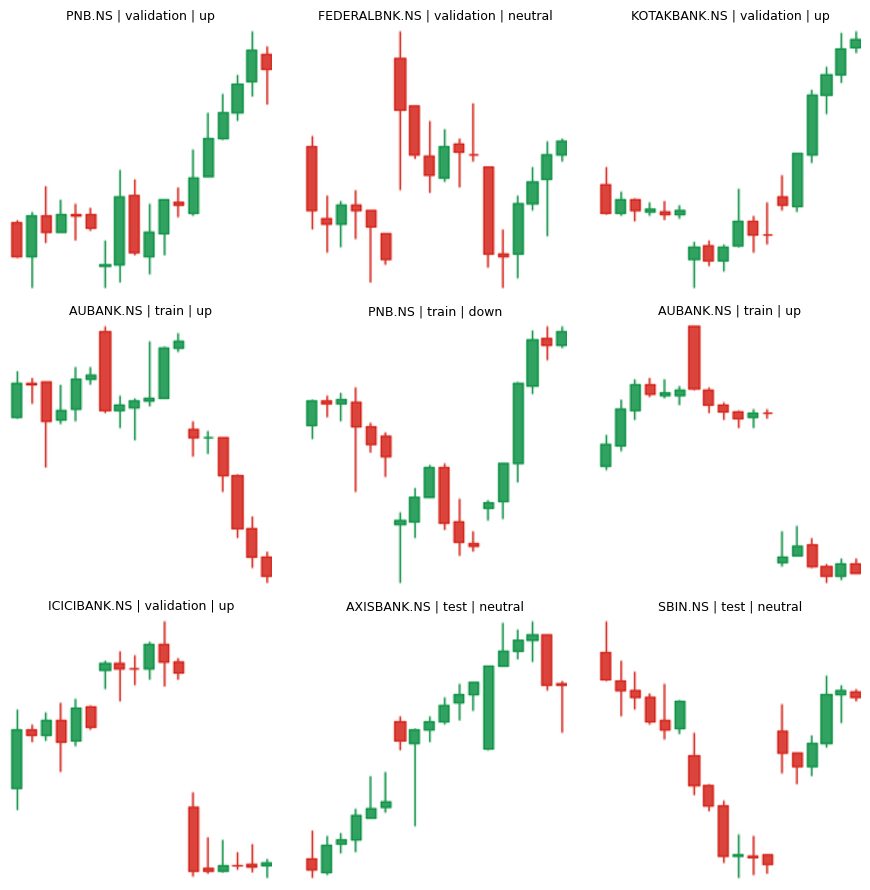

In [10]:
def preview_samples(metadata: pd.DataFrame, n: int = 9):
    preview_df = metadata.sample(min(n, len(metadata)), random_state=RANDOM_SEED).reset_index(drop=True)
    cols = min(3, len(preview_df))
    rows = math.ceil(len(preview_df) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, preview_df.iterrows()):
        image = Image.open(PROJECT_ROOT / row["image_path"])
        ax.imshow(image)
        ax.set_title(f"{row['ticker']} | {row['split']} | {row['label']}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(preview_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


preview_samples(metadata, n=9)

## Task 1, 2, and 3 Output

After running the notebook cells above, the dataset pipeline produces:

- Raw hourly CSV files in `data/raw_hourly/`.
- Multiclass candlestick images in `data/candlestick_images_multiclass/{train,validation,test}/{down,neutral,up}/`.
- A full sample index in `data/metadata_multiclass.csv`.
- Class mapping in `data/class_to_idx_multiclass.json`.
- Split manifests in `data/manifests_multiclass/`.
- A summary file in `data/dataset_summary_multiclass.json`.

Labeling strategy is clearly defined as:

```python
returns = close.pct_change()
vol = returns.rolling(20).std()
threshold = max(0.5 * vol, 0.003)
```

`up`, `down`, and `neutral` samples are all kept. Neutral is assigned when the next-day return is within the volatility threshold band.

The split section includes an assertion-based audit to prevent overlapping-window leakage across train, validation, and test. The dataset preparation section verifies that image folders and CSV labels match exactly.

## 10. Model Implementation

This section trains three image classifiers using the verified manifest files from Task 3:

- **Vision Transformer (ViT-B/16)** with ImageNet pretrained weights when available.
- **ResNet-18** with ImageNet pretrained weights when available.
- **Custom CNN** trained from scratch.

The target is three-class classification: `down`, `neutral`, and `up`.

In [17]:
import os
import time
from copy import deepcopy

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    from torchvision import models, transforms
except ImportError as exc:
    raise ImportError(
        "PyTorch/torchvision is required for Task 4. "
        "On Kaggle it is usually preinstalled; otherwise run `%pip install torch torchvision`."
    ) from exc

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(LABELS)
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_CONFIG = {
    "image_size": IMAGE_SIZE,
    "batch_size": 64,
    "num_epochs": 12,
    "num_workers": 2,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 1e-4,
    "gradient_clip_norm": 1.0,
}

# Model-specific tuning. The previous shared LR setup was too blunt: ViT, ResNet,
# and a from-scratch CNN usually need different learning rates.
MODEL_TUNING_CONFIGS = {
    "vit_b_16": [
        {
            "name": "vit_head_lr_3e-4",
            "learning_rate": 3e-4,
            "weight_decay": 1e-4,
            "label_smoothing": 0.03,
            "freeze_pretrained_backbone": True,
        },
        {
            "name": "vit_finetune_lr_3e-5",
            "learning_rate": 3e-5,
            "weight_decay": 5e-5,
            "label_smoothing": 0.03,
            "freeze_pretrained_backbone": False,
        },
    ],
    "resnet18": [
        {
            "name": "resnet_finetune_lr_1e-4",
            "learning_rate": 1e-4,
            "weight_decay": 1e-4,
            "label_smoothing": 0.03,
            "freeze_pretrained_backbone": False,
        },
        {
            "name": "resnet_head_lr_3e-4",
            "learning_rate": 3e-4,
            "weight_decay": 1e-4,
            "label_smoothing": 0.03,
            "freeze_pretrained_backbone": True,
        },
    ],
    "custom_cnn": [
        {
            "name": "cnn_lr_1e-3",
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "label_smoothing": 0.02,
            "freeze_pretrained_backbone": False,
        },
        {
            "name": "cnn_lr_3e-4",
            "learning_rate": 3e-4,
            "weight_decay": 1e-4,
            "label_smoothing": 0.02,
            "freeze_pretrained_backbone": False,
        },
    ],
}

print(f"Device: {DEVICE}")
print(f"Classes: {CLASS_TO_IDX}")
print(f"Training config: {TRAINING_CONFIG}")

Device: cuda
Classes: {'down': 0, 'neutral': 1, 'up': 2}
Training config: {'image_size': (224, 224), 'batch_size': 64, 'num_epochs': 12, 'num_workers': 2, 'early_stopping_patience': 4, 'early_stopping_min_delta': 0.0001, 'gradient_clip_norm': 1.0}


### Dataset and DataLoaders

In [18]:
class CandlestickManifestDataset(Dataset):
    def __init__(self, manifest_path: Path, transform=None):
        self.manifest_path = Path(manifest_path)
        self.samples = pd.read_csv(self.manifest_path)
        self.transform = transform

        if self.samples.empty:
            raise ValueError(f"Manifest is empty: {self.manifest_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]
        image = Image.open(PROJECT_ROOT / row["image_path"]).convert("RGB")
        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# Keep chart geometry and colors stable. Flips/rotations invert time or distort candles,
# and color jitter can corrupt the red/green candle signal.
imagenet_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
train_transform = imagenet_transform


def build_dataloaders(batch_size: int = TRAINING_CONFIG["batch_size"]):
    datasets = {
        "train": CandlestickManifestDataset(MANIFEST_DIR / "train.csv", transform=train_transform),
        "validation": CandlestickManifestDataset(MANIFEST_DIR / "validation.csv", transform=imagenet_transform),
        "test": CandlestickManifestDataset(MANIFEST_DIR / "test.csv", transform=imagenet_transform),
    }

    dataloaders = {
        "train": DataLoader(
            datasets["train"],
            batch_size=batch_size,
            shuffle=True,
            num_workers=TRAINING_CONFIG["num_workers"],
            pin_memory=torch.cuda.is_available(),
        ),
        "validation": DataLoader(
            datasets["validation"],
            batch_size=batch_size,
            shuffle=False,
            num_workers=TRAINING_CONFIG["num_workers"],
            pin_memory=torch.cuda.is_available(),
        ),
        "test": DataLoader(
            datasets["test"],
            batch_size=batch_size,
            shuffle=False,
            num_workers=TRAINING_CONFIG["num_workers"],
            pin_memory=torch.cuda.is_available(),
        ),
    }

    return datasets, dataloaders


def compute_class_weights(manifest_path: Path) -> torch.Tensor:
    train_manifest = pd.read_csv(manifest_path)
    counts = train_manifest["label_id"].value_counts().sort_index()
    weights = len(train_manifest) / (NUM_CLASSES * counts)
    return torch.tensor(weights.reindex(range(NUM_CLASSES)).values, dtype=torch.float32)


def describe_split_baselines():
    split_rows = []
    for split in ["train", "validation", "test"]:
        manifest = pd.read_csv(MANIFEST_DIR / f"{split}.csv")
        majority_label = manifest["label"].value_counts().idxmax()
        majority_accuracy = manifest["label"].value_counts(normalize=True).max()
        split_rows.append(
            {
                "split": split,
                "rows": len(manifest),
                "majority_label": majority_label,
                "majority_baseline_accuracy": majority_accuracy,
                **manifest["label"].value_counts().to_dict(),
            }
        )
    return pd.DataFrame(split_rows).fillna(0)


datasets, dataloaders = build_dataloaders()
class_weights = compute_class_weights(MANIFEST_DIR / "train.csv").to(DEVICE)
print({split: len(dataset) for split, dataset in datasets.items()})
print(f"Class weights: {class_weights.detach().cpu().numpy()}")
display(describe_split_baselines())

{'train': 4902, 'validation': 1365, 'test': 690}
Class weights: [1.20324    0.74003625 1.2230539 ]


,split,rows,majority_label,majority_baseline_accuracy,neutral,down,up
0,train,4902,neutral,0.450428,2208,1358,1336
1,validation,1365,neutral,0.452747,618,334,413
2,test,690,neutral,0.373913,258,235,197


### Model Definitions

In [19]:
def load_weights_safely(weights_enum, weights_name="DEFAULT"):
    try:
        return getattr(weights_enum, weights_name)
    except Exception:
        return None


def freeze_parameters(module: nn.Module):
    for parameter in module.parameters():
        parameter.requires_grad = False


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def build_vit_model(num_classes: int = NUM_CLASSES, freeze_pretrained_backbone: bool = True):
    weights_enum = getattr(models, "ViT_B_16_Weights", None)
    weights = load_weights_safely(weights_enum) if weights_enum is not None else None
    try:
        model = models.vit_b_16(weights=weights)
        pretrained = weights is not None
    except Exception as exc:
        print(f"Could not load ViT pretrained weights, using random initialization: {exc}")
        model = models.vit_b_16(weights=None)
        pretrained = False

    if pretrained and freeze_pretrained_backbone:
        freeze_parameters(model)

    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(0.20),
        nn.Linear(in_features, num_classes),
    )
    return model, pretrained


def build_resnet_model(num_classes: int = NUM_CLASSES, freeze_pretrained_backbone: bool = False):
    weights_enum = getattr(models, "ResNet18_Weights", None)
    weights = load_weights_safely(weights_enum) if weights_enum is not None else None
    try:
        model = models.resnet18(weights=weights)
        pretrained = weights is not None
    except Exception as exc:
        print(f"Could not load ResNet pretrained weights, using random initialization: {exc}")
        model = models.resnet18(weights=None)
        pretrained = False

    if pretrained and freeze_pretrained_backbone:
        freeze_parameters(model)

    model.fc = nn.Sequential(
        nn.Dropout(0.30),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model, pretrained


class CandlestickCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(384, 192),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(192, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_cnn_model(num_classes: int = NUM_CLASSES, freeze_pretrained_backbone: bool = False):
    return CandlestickCNN(num_classes=num_classes), False


MODEL_BUILDERS = {
    "vit_b_16": build_vit_model,
    "resnet18": build_resnet_model,
    "custom_cnn": build_cnn_model,
}

### Training and Evaluation Utilities

In [20]:
def make_criterion(config: dict):
    return nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config.get("label_smoothing", 0.0),
    )


def run_one_epoch(model, dataloader, criterion, optimizer=None, phase="train", epoch=None, total_epochs=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_correct = 0
    seen = 0
    all_targets = []
    all_predictions = []

    desc_bits = [phase]
    if epoch is not None and total_epochs is not None:
        desc_bits.append(f"epoch {epoch}/{total_epochs}")
    progress = tqdm(dataloader, desc=" | ".join(desc_bits), leave=False)

    with torch.set_grad_enabled(is_train):
        for images, labels in progress:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                if TRAINING_CONFIG["gradient_clip_norm"] is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), TRAINING_CONFIG["gradient_clip_norm"])
                optimizer.step()

            predictions = logits.argmax(dim=1)
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predictions == labels).sum().item()
            seen += batch_size

            all_targets.extend(labels.detach().cpu().numpy())
            all_predictions.extend(predictions.detach().cpu().numpy())

            progress.set_postfix(
                loss=running_loss / max(seen, 1),
                acc=running_correct / max(seen, 1),
            )

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_targets, all_predictions)
    epoch_balanced_accuracy = balanced_accuracy_score(all_targets, all_predictions)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_targets,
        all_predictions,
        average="weighted",
        zero_division=0,
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "balanced_accuracy": epoch_balanced_accuracy,
        "precision": weighted_precision,
        "recall": weighted_recall,
        "f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    }


def train_model(model_name: str, config: dict):
    model, pretrained = MODEL_BUILDERS[model_name](
        freeze_pretrained_backbone=config.get("freeze_pretrained_backbone", False)
    )
    model = model.to(DEVICE)

    criterion = make_criterion(config)
    trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = optim.AdamW(
        trainable_parameters,
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=TRAINING_CONFIG["num_epochs"],
        eta_min=config["learning_rate"] * 0.05,
    )

    best_state = deepcopy(model.state_dict())
    best_validation_score = -1.0
    patience_counter = 0
    history = []
    start_time = time.time()

    print(
        f"\nStarting {model_name} | {config['name']} | pretrained={pretrained} | "
        f"freeze_backbone={config.get('freeze_pretrained_backbone', False)} | "
        f"trainable_params={count_trainable_parameters(model):,}"
    )

    for epoch in range(1, TRAINING_CONFIG["num_epochs"] + 1):
        train_metrics = run_one_epoch(
            model,
            dataloaders["train"],
            criterion,
            optimizer=optimizer,
            phase=f"{model_name} train",
            epoch=epoch,
            total_epochs=TRAINING_CONFIG["num_epochs"],
        )
        validation_metrics = run_one_epoch(
            model,
            dataloaders["validation"],
            criterion,
            phase=f"{model_name} val",
            epoch=epoch,
            total_epochs=TRAINING_CONFIG["num_epochs"],
        )
        scheduler.step()

        row = {
            "model": model_name,
            "config": config["name"],
            "epoch": epoch,
            "pretrained": pretrained,
            "freeze_pretrained_backbone": config.get("freeze_pretrained_backbone", False),
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"validation_{key}": value for key, value in validation_metrics.items()},
        }
        history.append(row)

        print(
            f"{model_name} | {config['name']} | epoch {epoch:02d}: "
            f"train_acc={train_metrics['accuracy']:.4f}, val_acc={validation_metrics['accuracy']:.4f}, "
            f"train_f1={train_metrics['f1']:.4f}, val_f1={validation_metrics['f1']:.4f}, "
            f"val_macro_f1={validation_metrics['macro_f1']:.4f}, "
            f"train_loss={train_metrics['loss']:.4f}, val_loss={validation_metrics['loss']:.4f}"
        )

        validation_score = validation_metrics["macro_f1"]
        if validation_score > best_validation_score + TRAINING_CONFIG["early_stopping_min_delta"]:
            best_validation_score = validation_score
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= TRAINING_CONFIG["early_stopping_patience"]:
            print(f"Early stopping {model_name} | {config['name']} at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    test_metrics = run_one_epoch(model, dataloaders["test"], criterion, phase=f"{model_name} test")
    elapsed_minutes = (time.time() - start_time) / 60

    model_path = MODEL_DIR / f"{model_name}_{config['name']}.pth"
    torch.save(
        {
            "model_name": model_name,
            "config": config,
            "class_to_idx": CLASS_TO_IDX,
            "state_dict": model.state_dict(),
            "test_metrics": test_metrics,
        },
        model_path,
    )

    result = {
        "model": model_name,
        "config": config["name"],
        "pretrained": pretrained,
        "freeze_pretrained_backbone": config.get("freeze_pretrained_backbone", False),
        "best_validation_macro_f1": best_validation_score,
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "elapsed_minutes": elapsed_minutes,
        "model_path": str(model_path.relative_to(PROJECT_ROOT)),
    }

    return model, pd.DataFrame(history), result


def predict_with_model(model, dataloader):
    model.eval()
    targets = []
    predictions = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Predicting", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)
            predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
            targets.extend(labels.numpy())

    return np.array(targets), np.array(predictions)

### Why Accuracy Can Be Low

Low accuracy is expected in this problem if the split is leakage-safe. A few reasons:

- Next-day stock direction is noisy; news, macro moves, gaps, and sector events are not visible in the last 18 candles.
- The purged chronological split removes overlap leakage, so validation/test are harder but more honest.
- `neutral` is the largest class, so plain accuracy can be misleading. Compare against the majority-class baseline and also track macro F1 / balanced accuracy.
- ViT/ResNet are pretrained on natural images, not candlestick charts. They often need either careful fine-tuning or more data.
- A 3-day image may be too short to capture longer market context. Later experiments can try 5-day or 10-day windows.

### Train ViT, ResNet, and Custom CNN

This loop trains each model over the small hyperparameter set and keeps the best validation F1 checkpoint for each run.

In [21]:
TRAIN_MODELS_NOW = True
RUN_FULL_TUNING = True  # Set False to train only the first config for each model.
MODELS_TO_TRAIN = ["vit_b_16", "resnet18", "custom_cnn"]

all_histories = []
all_results = []
best_models = {}

if TRAIN_MODELS_NOW:
    for model_name in MODELS_TO_TRAIN:
        configs = MODEL_TUNING_CONFIGS[model_name]
        if not RUN_FULL_TUNING:
            configs = configs[:1]

        model_results = []
        outer_progress = tqdm(configs, desc=f"Tuning {model_name}")
        for config in outer_progress:
            outer_progress.set_postfix(config=config["name"])
            model, history, result = train_model(model_name, config)
            all_histories.append(history)
            all_results.append(result)
            model_results.append((result["best_validation_macro_f1"], model, result))

        best_validation_macro_f1, best_model, best_result = max(model_results, key=lambda item: item[0])
        best_models[model_name] = best_model
        print(
            f"Best {model_name}: {best_result['config']} "
            f"with val_macro_f1={best_validation_macro_f1:.4f}"
        )

    training_history = pd.concat(all_histories, ignore_index=True)
    model_results = pd.DataFrame(all_results).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

    training_history.to_csv(DATA_DIR / "training_history.csv", index=False)
    model_results.to_csv(DATA_DIR / "model_results.csv", index=False)

    display(model_results)
else:
    print("Set TRAIN_MODELS_NOW=True to train the models.")

Tuning vit_b_16:   0%|          | 0/2 [00:00<?, ?it/s]


Starting vit_b_16 | vit_head_lr_3e-4 | pretrained=True | freeze_backbone=True | trainable_params=2,307


vit_b_16 train | epoch 1/12:   0%|          | 0/77 [00:00<?, ?it/s]

vit_b_16 val | epoch 1/12:   0%|          | 0/22 [00:00<?, ?it/s]

vit_b_16 | vit_head_lr_3e-4 | epoch 01: train_acc=0.3260, val_acc=0.4051, train_f1=0.3302, val_f1=0.3140, val_macro_f1=0.2616, train_loss=1.1190, val_loss=1.1102


...

custom_cnn val | epoch 9/12:   0%|          | 0/22 [00:00<?, ?it/s]

custom_cnn | cnn_lr_3e-4 | epoch 09: train_acc=0.3772, val_acc=0.3099, train_f1=0.3511, val_f1=0.1739, val_macro_f1=0.1803, train_loss=1.0660, val_loss=1.1846
Early stopping custom_cnn | cnn_lr_3e-4 at epoch 9


custom_cnn test:   0%|          | 0/11 [00:00<?, ?it/s]

Best custom_cnn: cnn_lr_3e-4 with val_macro_f1=0.3527


,model,config,pretrained,freeze_pretrained_backbone,best_validation_macro_f1,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_macro_f1,elapsed_minutes,model_path
0,vit_b_16,vit_finetune_lr_3e-5,True,False,0.324874,0.350725,0.347730,0.352010,0.350725,0.350409,0.346554,43.508344,data/models/vit_b_16_vit_finetune_lr_3e-5.pth
1,resnet18,resnet_finetune_lr_1e-4,True,False,0.336588,0.318841,0.328713,0.340067,0.318841,0.311057,0.312966,1.672860,data/models/resnet18_resnet_finetune_lr_1e-4.pth
2,custom_cnn,cnn_lr_3e-4,False,False,0.352687,0.342029,0.322457,0.323146,0.342029,0.316565,0.303854,2.530251,data/models/custom_cnn_cnn_lr_3e-4.pth
3,resnet18,resnet_head_lr_3e-4,True,True,0.347504,0.324638,0.322824,0.333916,0.324638,0.302960,0.300076,1.496053,data/models/resnet18_resnet_head_lr_3e-4.pth
4,vit_b_16,vit_head_lr_3e-4,True,True,0.302148,0.326087,0.308394,0.306219,0.326087,0.303637,0.291052,12.719952,data/models/vit_b_16_vit_head_lr_3e-4.pth
5,custom_cnn,cnn_lr_1e-3,False,False,0.287931,0.313043,0.337676,0.328106,0.313043,0.274178,0.285623,1.660860,data/models/custom_cnn_cnn_lr_1e-3.pth


### Test Set Reports

In [24]:
if TRAIN_MODELS_NOW and best_models:
    for model_name, model in best_models.items():
        y_true, y_pred = predict_with_model(model, dataloaders["test"])
        print(f"\n=== {model_name} test classification report ===")
        print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
        print("Confusion matrix:")
        print(pd.DataFrame(confusion_matrix(y_true, y_pred), index=LABELS, columns=LABELS))
else:
    print("No trained models available yet.")

Predicting:   0%|          | 0/11 [00:00<?, ?it/s]


=== vit_b_16 test classification report ===
              precision    recall  f1-score   support

        down       0.37      0.41      0.39       235
     neutral       0.39      0.34      0.36       258
          up       0.28      0.29      0.29       197

    accuracy                           0.35       690
   macro avg       0.35      0.35      0.35       690
weighted avg       0.35      0.35      0.35       690

Confusion matrix:
         down  neutral  up
down       97       72  66
neutral    92       88  78
up         73       67  57


Predicting:   0%|          | 0/11 [00:00<?, ?it/s]


=== resnet18 test classification report ===
              precision    recall  f1-score   support

        down       0.36      0.11      0.17       235
     neutral       0.36      0.47      0.41       258
          up       0.27      0.38      0.32       197

    accuracy                           0.32       690
   macro avg       0.33      0.32      0.30       690
weighted avg       0.33      0.32      0.30       690

Confusion matrix:
         down  neutral   up
down       27      116   92
neutral    24      122  112
up         25       97   75


Predicting:   0%|          | 0/11 [00:00<?, ?it/s]


=== custom_cnn test classification report ===
              precision    recall  f1-score   support

        down       0.35      0.28      0.31       235
     neutral       0.36      0.57      0.44       258
          up       0.24      0.12      0.16       197

    accuracy                           0.34       690
   macro avg       0.32      0.32      0.30       690
weighted avg       0.32      0.34      0.32       690

Confusion matrix:
         down  neutral  up
down       66      133  36
neutral    75      147  36
up         49      125  23


## 11. Explainability (XAI)

This section explains model decisions on candlestick images.

- For ResNet and the custom CNN, it uses **Grad-CAM** on the last convolutional layer.
- For ViT, it uses an input-gradient saliency map as an attention-style visualization, because torchvision ViT does not expose attention weights during normal forward passes.

The heatmaps show which image regions most influenced the predicted class.

In [25]:
def load_best_model_from_results(results_path: Path = DATA_DIR / "model_results.csv"):
    if not results_path.exists():
        raise FileNotFoundError(
            f"{results_path} not found. Run the model training cell first, or point to an existing checkpoint."
        )

    results = pd.read_csv(results_path).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
    best_row = results.iloc[0]
    checkpoint_path = PROJECT_ROOT / best_row["model_path"]

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model_name = checkpoint["model_name"]
    config = checkpoint["config"]

    model, pretrained = MODEL_BUILDERS[model_name](
        freeze_pretrained_backbone=config.get("freeze_pretrained_backbone", False)
    )
    model.load_state_dict(checkpoint["state_dict"])
    model = model.to(DEVICE)
    model.eval()

    print(f"Loaded best checkpoint: {checkpoint_path}")
    print(f"Model: {model_name} | config: {config['name']} | pretrained={pretrained}")
    return model_name, model, checkpoint, results


if "best_models" in globals() and best_models:
    best_model_name = max(
        all_results,
        key=lambda row: row.get("test_macro_f1", row.get("test_f1", -1)),
    )["model"]
    xai_model = best_models[best_model_name].to(DEVICE).eval()
    model_results_table = pd.DataFrame(all_results).sort_values("test_macro_f1", ascending=False)
    print(f"Using best in-memory model: {best_model_name}")
else:
    best_model_name, xai_model, best_checkpoint, model_results_table = load_best_model_from_results()

idx_to_class = {idx: label for label, idx in CLASS_TO_IDX.items()}
display(model_results_table.head())

Using best in-memory model: vit_b_16


,model,config,pretrained,freeze_pretrained_backbone,best_validation_macro_f1,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_macro_f1,elapsed_minutes,model_path
1,vit_b_16,vit_finetune_lr_3e-5,True,False,0.324874,0.350725,0.347730,0.352010,0.350725,0.350409,0.346554,43.508344,data/models/vit_b_16_vit_finetune_lr_3e-5.pth
2,resnet18,resnet_finetune_lr_1e-4,True,False,0.336588,0.318841,0.328713,0.340067,0.318841,0.311057,0.312966,1.672860,data/models/resnet18_resnet_finetune_lr_1e-4.pth
5,custom_cnn,cnn_lr_3e-4,False,False,0.352687,0.342029,0.322457,0.323146,0.342029,0.316565,0.303854,2.530251,data/models/custom_cnn_cnn_lr_3e-4.pth
3,resnet18,resnet_head_lr_3e-4,True,True,0.347504,0.324638,0.322824,0.333916,0.324638,0.302960,0.300076,1.496053,data/models/resnet18_resnet_head_lr_3e-4.pth
0,vit_b_16,vit_head_lr_3e-4,True,True,0.302148,0.326087,0.308394,0.306219,0.326087,0.303637,0.291052,12.719952,data/models/vit_b_16_vit_head_lr_3e-4.pth


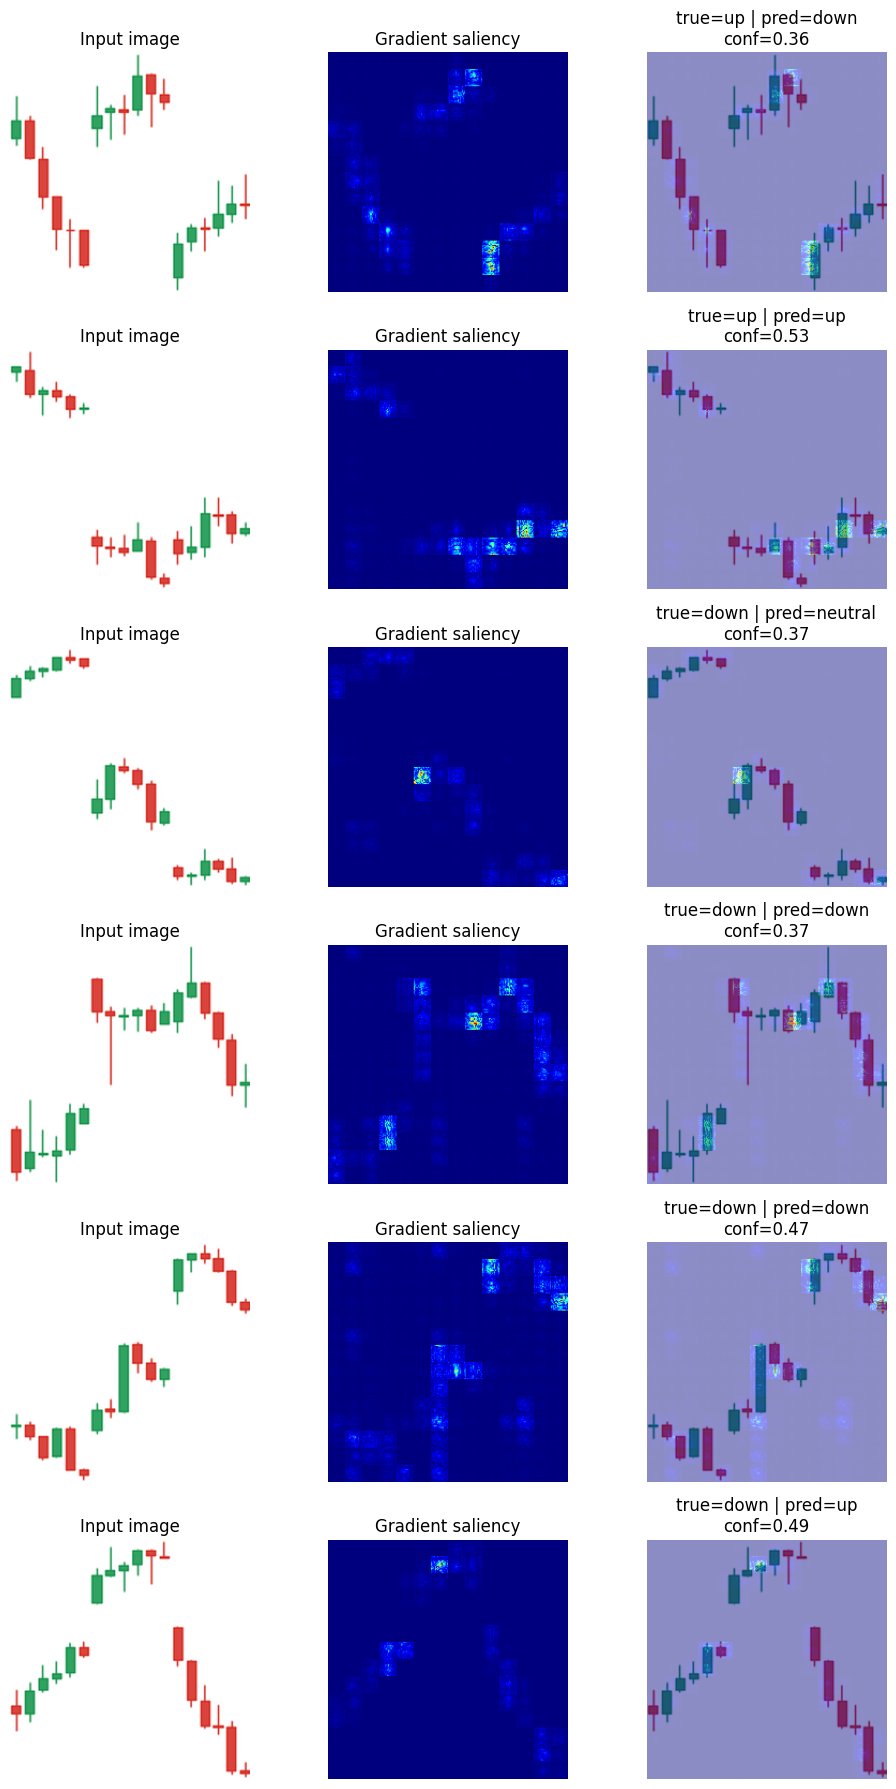

In [26]:
def denormalize_image(tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __call__(self, input_tensor: torch.Tensor, class_idx: int = None):
        self.model.zero_grad(set_to_none=True)
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach()


def get_gradcam_target_layer(model_name: str, model: nn.Module):
    if model_name == "resnet18":
        return model.layer4[-1]
    if model_name == "custom_cnn":
        return model.features[-4]
    return None


def gradient_saliency(model: nn.Module, input_tensor: torch.Tensor, class_idx: int = None):
    model.zero_grad(set_to_none=True)
    saliency_input = input_tensor.clone().detach().requires_grad_(True)
    logits = model(saliency_input)
    if class_idx is None:
        class_idx = int(logits.argmax(dim=1).item())
    logits[:, class_idx].sum().backward()
    saliency = saliency_input.grad.detach().abs().max(dim=1)[0].squeeze().cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency, logits.detach()


def overlay_heatmap(image: np.ndarray, heatmap: np.ndarray, alpha: float = 0.45):
    cmap = plt.get_cmap("jet")
    colored_heatmap = cmap(heatmap)[..., :3]
    return np.clip((1 - alpha) * image + alpha * colored_heatmap, 0, 1)


def explain_single_sample(model_name: str, model: nn.Module, dataset: Dataset, index: int):
    image_tensor, true_label_id = dataset[index]
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    target_layer = get_gradcam_target_layer(model_name, model)
    if target_layer is not None:
        cam = GradCAM(model, target_layer)
        heatmap, logits = cam(input_tensor)
        cam.remove_hooks()
        method = "Grad-CAM"
    else:
        heatmap, logits = gradient_saliency(model, input_tensor)
        method = "Gradient saliency"

    probabilities = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    predicted_label_id = int(probabilities.argmax())
    image = denormalize_image(image_tensor)
    overlay = overlay_heatmap(image, heatmap)

    return {
        "image": image,
        "heatmap": heatmap,
        "overlay": overlay,
        "method": method,
        "true_label": idx_to_class[int(true_label_id)],
        "predicted_label": idx_to_class[predicted_label_id],
        "confidence": float(probabilities[predicted_label_id]),
    }


def visualize_xai_samples(model_name: str, model: nn.Module, dataset: Dataset, n: int = 6, seed: int = RANDOM_SEED):
    rng = np.random.default_rng(seed)
    sample_indices = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    rows = len(sample_indices)
    fig, axes = plt.subplots(rows, 3, figsize=(10, rows * 3))
    if rows == 1:
        axes = np.array([axes])

    for row_idx, sample_idx in enumerate(sample_indices):
        explanation = explain_single_sample(model_name, model, dataset, int(sample_idx))
        axes[row_idx, 0].imshow(explanation["image"])
        axes[row_idx, 0].set_title("Input image")
        axes[row_idx, 1].imshow(explanation["heatmap"], cmap="jet")
        axes[row_idx, 1].set_title(explanation["method"])
        axes[row_idx, 2].imshow(explanation["overlay"])
        axes[row_idx, 2].set_title(
            f"true={explanation['true_label']} | pred={explanation['predicted_label']}\n"
            f"conf={explanation['confidence']:.2f}"
        )
        for col in range(3):
            axes[row_idx, col].axis("off")

    plt.tight_layout()
    plt.show()


visualize_xai_samples(best_model_name, xai_model, datasets["test"], n=6)

### XAI Interpretation Notes

Use these visualizations to answer: which candlestick areas influenced the model most?

Typical things to look for:
- Does the heatmap focus on recent candles near the right side of the image?
- Does it attend to candle bodies, long wicks, gaps, or sudden trend changes?
- Does it focus on empty chart background? If yes, the model may be learning artifacts rather than price structure.
- For wrong predictions, compare whether attention is diffuse or concentrated on misleading candles.

## 12. Evaluation and Analysis

This section evaluates the selected model using Accuracy, Precision, Recall, and F1-score, then visualizes correct and incorrect predictions.

In [27]:
def evaluate_model_on_split(model: nn.Module, dataloader: DataLoader, split: str):
    y_true, y_pred = predict_with_model(model, dataloader)
    manifest = dataloader.dataset.samples.reset_index(drop=True).copy()
    probabilities = []

    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Probabilities {split}", leave=False):
            logits = model(images.to(DEVICE, non_blocking=True))
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())

    probabilities = np.vstack(probabilities)
    confidence = probabilities.max(axis=1)

    eval_df = manifest.copy()
    eval_df["true_label"] = [idx_to_class[int(idx)] for idx in y_true]
    eval_df["pred_label"] = [idx_to_class[int(idx)] for idx in y_pred]
    eval_df["confidence"] = confidence
    eval_df["correct"] = eval_df["true_label"] == eval_df["pred_label"]

    metrics = {
        "split": split,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    metrics.update(
        {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "macro_f1": macro_f1,
        }
    )

    print(f"\n=== {split.upper()} evaluation ===")
    print(pd.Series(metrics))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_true, y_pred), index=LABELS, columns=LABELS))

    return metrics, eval_df


evaluation_metrics = []
evaluation_frames = {}
for split in ["train", "validation", "test"]:
    metrics, split_eval = evaluate_model_on_split(xai_model, dataloaders[split], split)
    evaluation_metrics.append(metrics)
    evaluation_frames[split] = split_eval

evaluation_metrics = pd.DataFrame(evaluation_metrics)
evaluation_metrics.to_csv(DATA_DIR / "evaluation_metrics.csv", index=False)
evaluation_frames["test"].to_csv(DATA_DIR / "test_predictions.csv", index=False)
display(evaluation_metrics)

Predicting:   0%|          | 0/77 [00:00<?, ?it/s]

Probabilities train:   0%|          | 0/77 [00:00<?, ?it/s]


=== TRAIN evaluation ===
split                   train
accuracy             0.446552
balanced_accuracy    0.455776
precision             0.46175
recall               0.446552
f1                   0.445976
macro_precision      0.448348
macro_recall         0.455776
macro_f1             0.443951
dtype: object

Classification report:
              precision    recall  f1-score   support

        down       0.39      0.56      0.46      1358
     neutral       0.53      0.40      0.45      2208
          up       0.43      0.40      0.42      1336

    accuracy                           0.45      4902
   macro avg       0.45      0.46      0.44      4902
weighted avg       0.46      0.45      0.45      4902

Confusion matrix:


,down,neutral,up
down,762,414,182
neutral,790,886,532
up,408,387,541


Predicting:   0%|          | 0/22 [00:00<?, ?it/s]

...

Predicting:   0%|          | 0/11 [00:00<?, ?it/s]

Probabilities test:   0%|          | 0/11 [00:00<?, ?it/s]


=== TEST evaluation ===
split                    test
accuracy             0.350725
balanced_accuracy     0.34773
precision             0.35201
recall               0.350725
f1                   0.350409
macro_precision      0.347159
macro_recall          0.34773
macro_f1             0.346554
dtype: object

Classification report:
              precision    recall  f1-score   support

        down       0.37      0.41      0.39       235
     neutral       0.39      0.34      0.36       258
          up       0.28      0.29      0.29       197

    accuracy                           0.35       690
   macro avg       0.35      0.35      0.35       690
weighted avg       0.35      0.35      0.35       690

Confusion matrix:


,down,neutral,up
down,97,72,66
neutral,92,88,78
up,73,67,57


,split,accuracy,balanced_accuracy,precision,recall,f1,macro_precision,macro_recall,macro_f1
0,train,0.446552,0.455776,0.461750,0.446552,0.445976,0.448348,0.455776,0.443951
1,validation,0.331136,0.333137,0.353017,0.331136,0.334864,0.332812,0.333137,0.324874
2,test,0.350725,0.347730,0.352010,0.350725,0.350409,0.347159,0.347730,0.346554


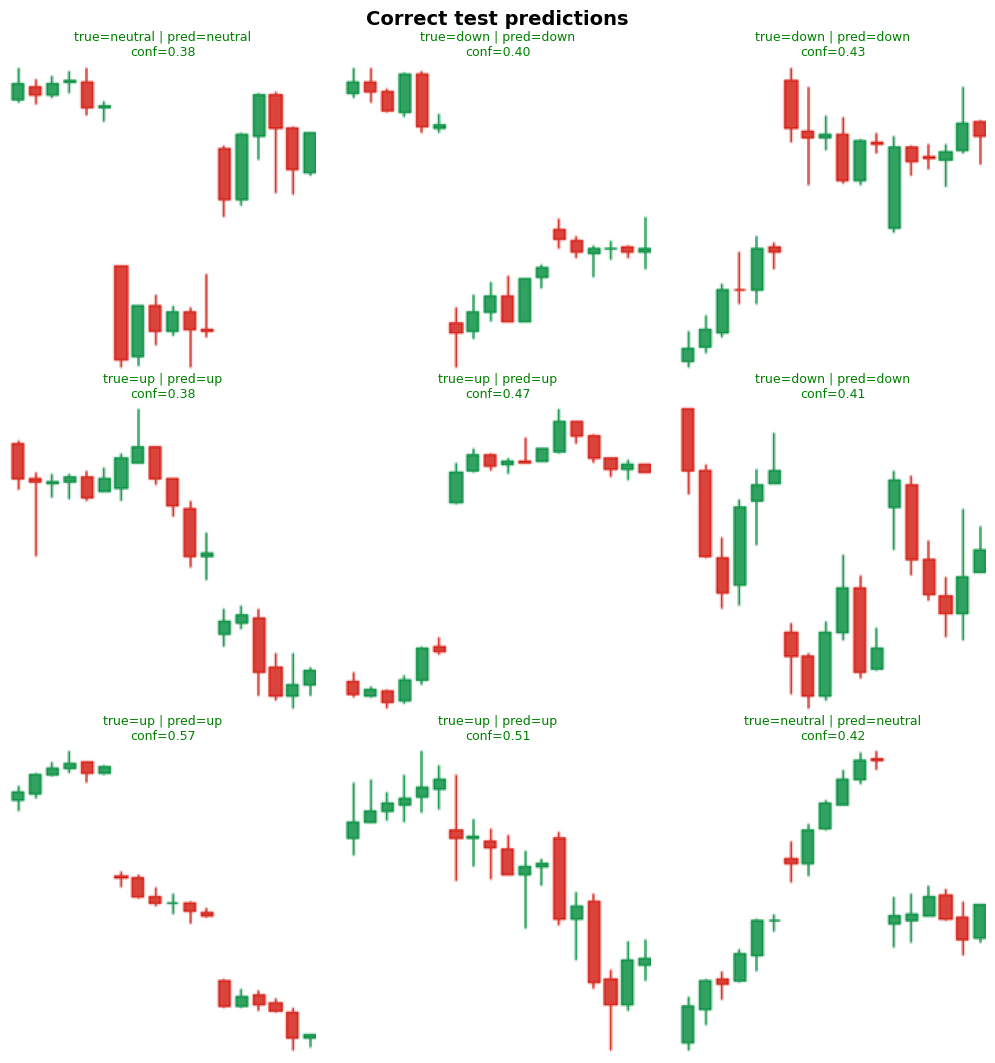

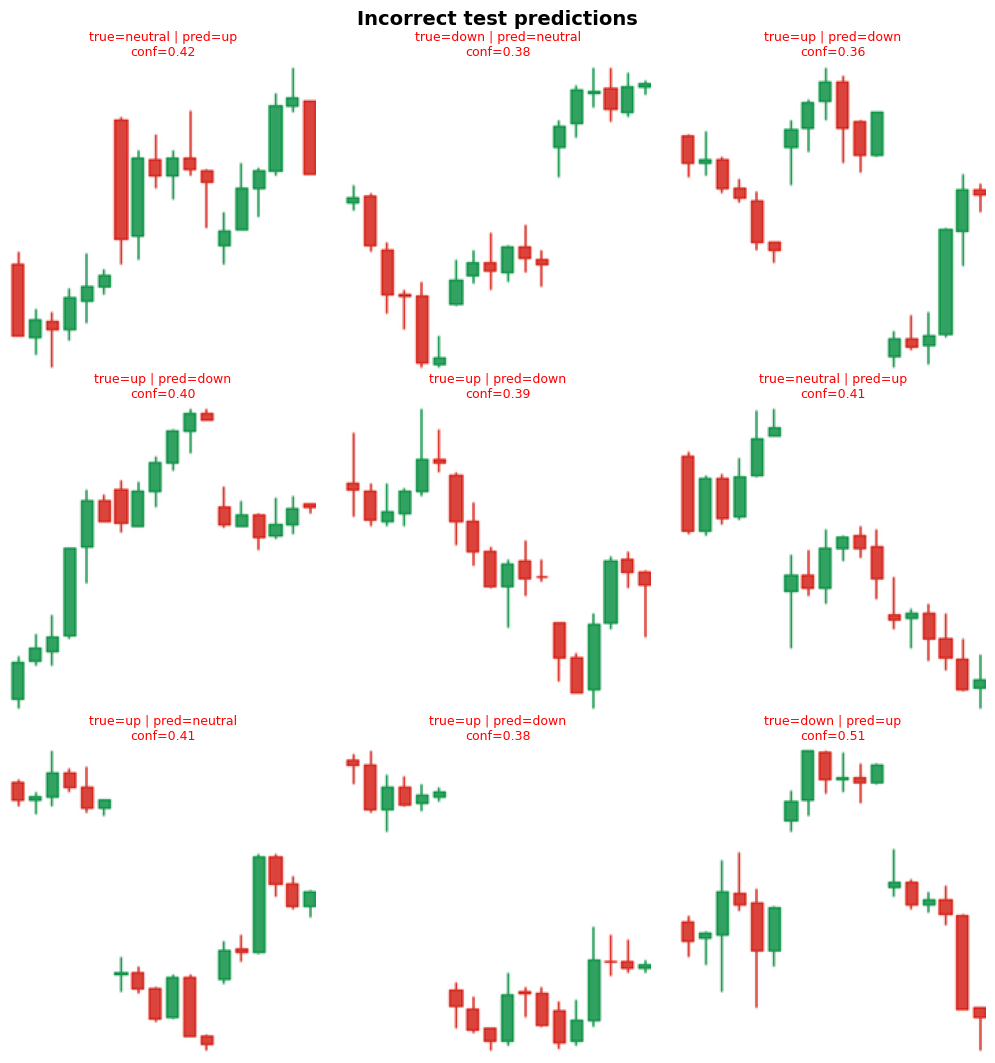

,true_label,pred_label,count
0,down,down,97
3,neutral,down,92
4,neutral,neutral,88
5,neutral,up,78
6,up,down,73
1,down,neutral,72
7,up,neutral,67
2,down,up,66
8,up,up,57


In [28]:
def visualize_prediction_grid(eval_df: pd.DataFrame, title: str, n: int = 9, seed: int = RANDOM_SEED):
    if eval_df.empty:
        print(f"No samples to show for {title}")
        return

    sample_df = eval_df.sample(min(n, len(eval_df)), random_state=seed).reset_index(drop=True)
    cols = 3
    rows = math.ceil(len(sample_df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.4, rows * 3.6))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(PROJECT_ROOT / row["image_path"]).convert("RGB")
        ax.imshow(image)
        color = "green" if row["correct"] else "red"
        ax.set_title(
            f"true={row['true_label']} | pred={row['pred_label']}\nconf={row['confidence']:.2f}",
            color=color,
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


test_eval = evaluation_frames["test"]
visualize_prediction_grid(test_eval[test_eval["correct"]], "Correct test predictions", n=9)
visualize_prediction_grid(test_eval[~test_eval["correct"]], "Incorrect test predictions", n=9)

error_summary = (
    test_eval.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(error_summary)

### Evaluation Interpretation Notes

Use the tables above to discuss:
- Which class is easiest or hardest: `down`, `neutral`, or `up`?
- Is the model mostly predicting the majority `neutral` class?
- Are `up` and `down` being confused with `neutral`, which would suggest the threshold band is difficult visually?
- Do incorrect predictions have low confidence? If yes, uncertainty is meaningful; if no, the model is overconfident.

## 13. Comparative Study with Traditional Candlestick Patterns

This section computes simple classical candlestick patterns from the same 18-candle input windows and compares them with labels and model predictions.

Patterns included:
- **Doji**: very small candle body relative to high-low range.
- **Hammer**: long lower wick, small upper wick, and body near the top of the range.
- **Engulfing**: current candle body engulfs the previous candle body.

In [29]:
RAW_DATA_CACHE = {}


def load_raw_hourly_for_ticker(ticker: str) -> pd.DataFrame:
    if ticker in RAW_DATA_CACHE:
        return RAW_DATA_CACHE[ticker]

    raw_path = RAW_DIR / f"{safe_ticker_name(ticker)}_{YFINANCE_INTERVAL}.csv"
    if not raw_path.exists():
        raise FileNotFoundError(f"Raw data not found for {ticker}: {raw_path}")
    df = pd.read_csv(raw_path, parse_dates=["DatetimeIST"], index_col="DatetimeIST")
    df = ensure_ist_index(df)
    RAW_DATA_CACHE[ticker] = df
    return df


def get_window_from_manifest_row(row: pd.Series) -> pd.DataFrame:
    df = load_raw_hourly_for_ticker(row["ticker"])
    session_df = df.between_time(MARKET_OPEN, MARKET_CLOSE).copy()
    context_dates = row["context_dates"].split("|")
    window_parts = []

    for date_str in context_dates:
        day_df = session_df[session_df.index.date == pd.to_datetime(date_str).date()].sort_index()
        if len(day_df) < CANDLES_PER_DAY:
            continue
        window_parts.append(day_df.iloc[-CANDLES_PER_DAY:][REQUIRED_COLUMNS].copy())

    if not window_parts:
        return pd.DataFrame(columns=REQUIRED_COLUMNS)

    return pd.concat(window_parts)


def candle_features(candle: pd.Series):
    open_price = float(candle["Open"])
    high_price = float(candle["High"])
    low_price = float(candle["Low"])
    close_price = float(candle["Close"])
    body = abs(close_price - open_price)
    candle_range = max(high_price - low_price, 1e-8)
    upper_wick = high_price - max(open_price, close_price)
    lower_wick = min(open_price, close_price) - low_price
    return open_price, high_price, low_price, close_price, body, candle_range, upper_wick, lower_wick


def is_doji(candle: pd.Series, body_ratio: float = 0.10) -> bool:
    *_, body, candle_range, _, _ = candle_features(candle)
    return (body / candle_range) <= body_ratio


def is_hammer(candle: pd.Series) -> bool:
    open_price, high_price, low_price, close_price, body, candle_range, upper_wick, lower_wick = candle_features(candle)
    if candle_range <= 0:
        return False
    return (
        lower_wick >= 2.0 * max(body, 1e-8)
        and upper_wick <= 0.35 * max(body, 1e-8)
        and max(open_price, close_price) >= low_price + 0.60 * candle_range
    )


def is_bullish_engulfing(previous: pd.Series, current: pd.Series) -> bool:
    prev_open, _, _, prev_close, *_ = candle_features(previous)
    curr_open, _, _, curr_close, *_ = candle_features(current)
    return (
        prev_close < prev_open
        and curr_close > curr_open
        and curr_open <= prev_close
        and curr_close >= prev_open
    )


def is_bearish_engulfing(previous: pd.Series, current: pd.Series) -> bool:
    prev_open, _, _, prev_close, *_ = candle_features(previous)
    curr_open, _, _, curr_close, *_ = candle_features(current)
    return (
        prev_close > prev_open
        and curr_close < curr_open
        and curr_open >= prev_close
        and curr_close <= prev_open
    )


def detect_classical_patterns(window_df: pd.DataFrame) -> dict:
    if len(window_df) < 2:
        return {
            "doji_last": False,
            "hammer_last": False,
            "bullish_engulfing_last": False,
            "bearish_engulfing_last": False,
            "any_doji_in_window": False,
            "any_hammer_in_window": False,
            "any_bullish_engulfing_in_window": False,
            "any_bearish_engulfing_in_window": False,
        }

    last = window_df.iloc[-1]
    previous = window_df.iloc[-2]
    doji_flags = [is_doji(row) for _, row in window_df.iterrows()]
    hammer_flags = [is_hammer(row) for _, row in window_df.iterrows()]

    bullish_engulfing_flags = [False]
    bearish_engulfing_flags = [False]
    for idx in range(1, len(window_df)):
        bullish_engulfing_flags.append(is_bullish_engulfing(window_df.iloc[idx - 1], window_df.iloc[idx]))
        bearish_engulfing_flags.append(is_bearish_engulfing(window_df.iloc[idx - 1], window_df.iloc[idx]))

    return {
        "doji_last": is_doji(last),
        "hammer_last": is_hammer(last),
        "bullish_engulfing_last": is_bullish_engulfing(previous, last),
        "bearish_engulfing_last": is_bearish_engulfing(previous, last),
        "any_doji_in_window": any(doji_flags),
        "any_hammer_in_window": any(hammer_flags),
        "any_bullish_engulfing_in_window": any(bullish_engulfing_flags),
        "any_bearish_engulfing_in_window": any(bearish_engulfing_flags),
    }


def build_pattern_comparison(eval_df: pd.DataFrame, max_rows: int = None):
    rows = []
    input_df = eval_df.reset_index(drop=True)
    if max_rows is not None:
        input_df = input_df.head(max_rows)

    for _, row in tqdm(input_df.iterrows(), total=len(input_df), desc="Detecting classical patterns"):
        window_df = get_window_from_manifest_row(row)
        pattern_row = row.to_dict()
        pattern_row.update(detect_classical_patterns(window_df))
        rows.append(pattern_row)

    return pd.DataFrame(rows)


pattern_comparison = build_pattern_comparison(evaluation_frames["test"])
pattern_comparison.to_csv(DATA_DIR / "traditional_pattern_comparison.csv", index=False)
pattern_columns = [column for column in pattern_comparison.columns if column.endswith("_last") or column.startswith("any_")]
pattern_comparison[pattern_columns + ["true_label", "pred_label", "correct"]].head()

Detecting classical patterns:   0%|          | 0/690 [00:00<?, ?it/s]

,doji_last,hammer_last,bullish_engulfing_last,bearish_engulfing_last,any_doji_in_window,any_hammer_in_window,any_bullish_engulfing_in_window,any_bearish_engulfing_in_window,true_label,pred_label,correct
0,True,False,False,False,True,True,True,True,up,down,False
1,False,False,False,False,True,False,True,True,neutral,down,False
2,False,False,False,False,True,False,True,True,up,down,False
3,True,True,False,False,True,True,True,False,down,down,True
4,False,False,False,False,True,True,True,False,up,up,True


In [30]:
def summarize_pattern_relationships(pattern_df: pd.DataFrame):
    pattern_columns = [column for column in pattern_df.columns if column.endswith("_last") or column.startswith("any_")]
    summaries = []

    for pattern in pattern_columns:
        subset = pattern_df[pattern_df[pattern]]
        if subset.empty:
            summaries.append(
                {
                    "pattern": pattern,
                    "count": 0,
                    "accuracy_when_present": np.nan,
                    "most_common_true_label": None,
                    "most_common_pred_label": None,
                }
            )
            continue

        summaries.append(
            {
                "pattern": pattern,
                "count": int(len(subset)),
                "accuracy_when_present": float(subset["correct"].mean()),
                "most_common_true_label": subset["true_label"].value_counts().idxmax(),
                "most_common_pred_label": subset["pred_label"].value_counts().idxmax(),
            }
        )

    return pd.DataFrame(summaries).sort_values("count", ascending=False)


pattern_summary = summarize_pattern_relationships(pattern_comparison)
display(pattern_summary)

for pattern in pattern_summary["pattern"]:
    subset = pattern_comparison[pattern_comparison[pattern]]
    if len(subset) == 0:
        continue
    print(f"\n{pattern}")
    display(pd.crosstab(subset["true_label"], subset["pred_label"], margins=True))

,pattern,count,accuracy_when_present,most_common_true_label,most_common_pred_label
4,any_doji_in_window,628,0.361465,neutral,down
7,any_bearish_engulfing_in_window,498,0.353414,neutral,down
6,any_bullish_engulfing_in_window,464,0.357759,neutral,down
5,any_hammer_in_window,289,0.363322,neutral,down
0,doji_last,125,0.320000,neutral,down
1,hammer_last,47,0.297872,down,down
3,bearish_engulfing_last,32,0.250000,down,down
2,bullish_engulfing_last,18,0.500000,up,neutral



any_doji_in_window


pred_label,down,neutral,up,All
true_label,,,,
down,94,67,60,221
neutral,81,81,69,231
up,65,59,52,176
All,240,207,181,628



any_bearish_engulfing_in_window


pred_label,down,neutral,up,All
true_label,,,,
down,72,51,53,176
neutral,68,63,59,190
up,48,43,41,132
All,188,157,153,498


...

pred_label,down,neutral,up,All
true_label,,,,
down,7,8,2,17
neutral,7,3,6,16
up,5,5,4,14
All,19,16,12,47



bearish_engulfing_last


pred_label,down,neutral,up,All
true_label,,,,
down,4,3,5,12
neutral,6,2,4,12
up,3,3,2,8
All,13,8,11,32



bullish_engulfing_last


pred_label,down,neutral,up,All
true_label,,,,
down,2,2,1,5
neutral,1,3,0,4
up,3,2,4,9
All,6,7,5,18


### Comparative Study Discussion Guide

Use the pattern summary to write the assignment discussion:

- **Doji** often maps to uncertainty, so it may align with `neutral`, but this is not guaranteed because the label is based on the next day.
- **Hammer** is traditionally interpreted as a possible bullish reversal, so check whether hammer windows have more `up` labels or more `up` predictions.
- **Bullish engulfing** should be compared against `up`; **bearish engulfing** against `down`.
- If the deep model predicts correctly even when no classical pattern is detected, that suggests it may be using non-classical structures such as multi-candle slope, volatility contraction/expansion, wick clusters, or gap-like behavior.
- If the model fails on obvious classical patterns, it may need longer lookback windows, volume panels, or more samples.